###**DIP Practical-14**

**Name:** Yesha Pandya

**Enrollment Number:** 23BT04175

**Div:** 1 **Batch:** C

**Objective:**

Develop an application for locating roadways, Road markings, Identifying Road Signs, Locating pedestrians

Original Street Scene:


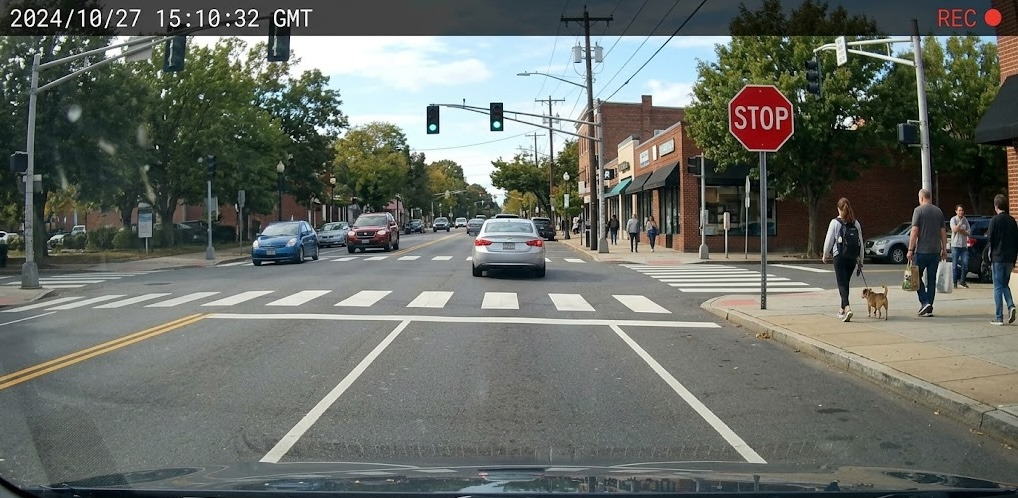

In [3]:
# import libraries
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# load image
original_img = cv2.imread("street scene.jpeg")

# make a copy of the original image
display_img = original_img.copy() # we'll draw all our final detections on this copy

print("Original Street Scene:")
cv2_imshow(original_img)

#### Locate Roadways and Road Markings
Steps to find lane markings:
- Use **Canny Edge Detection** to find sharp intensity changes
- Then find a **Region of Interest (ROI) Mask** (since lanes are usually in the bottom half of the camera view)
- Finally use the **Hough Line Transform** to mathematically detect the straight lines representing the road markings

Locating Roadways:


Grayscale Image:


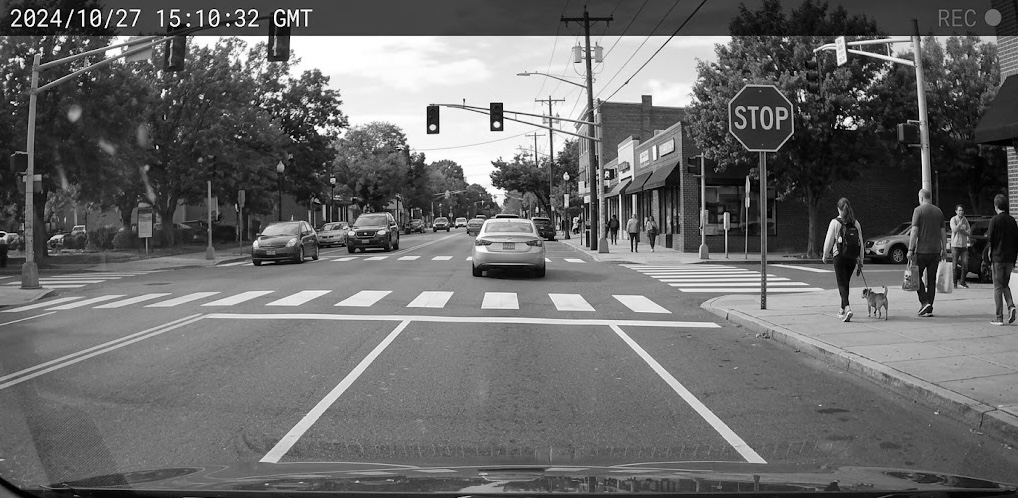


Canny Edge Detection:


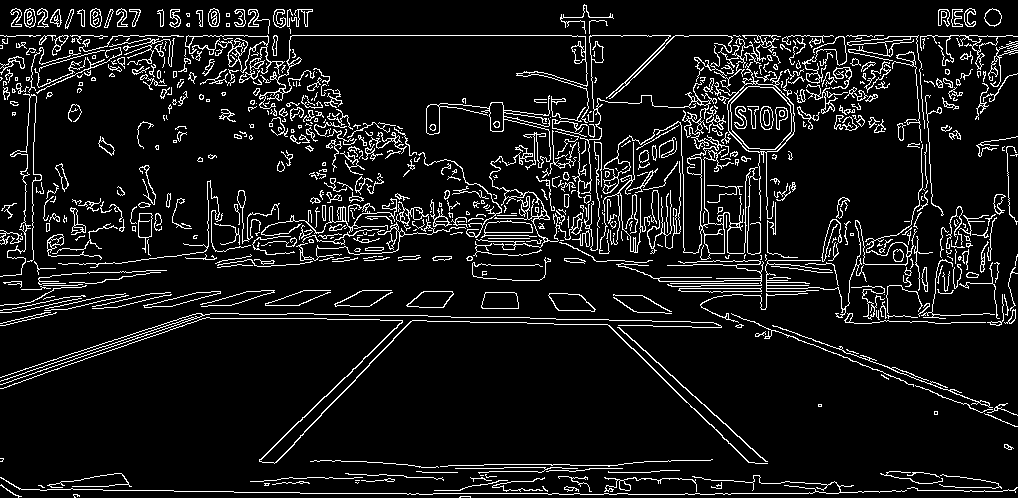


Region of Interest (Cropped Edges):


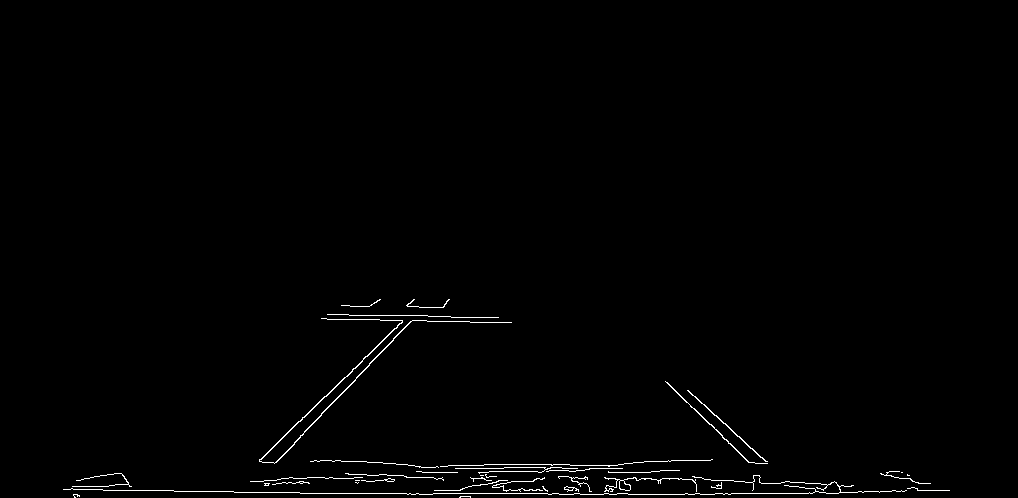


Detected Road Markings:


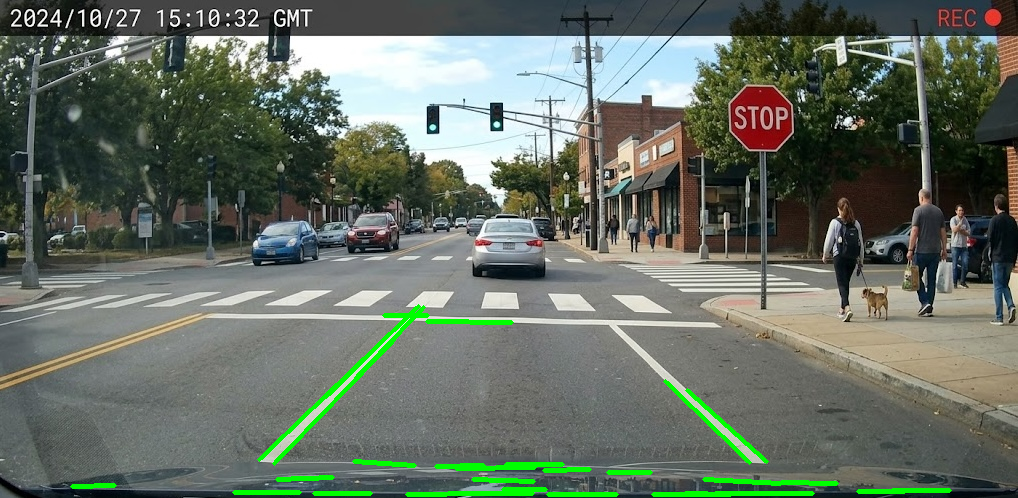

In [7]:
print("Locating Roadways:\n")

# convert to grayscale
gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
print("\nGrayscale Image:")
cv2_imshow(gray)

# apply Gaussian Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Canny Edge Detection
edges = cv2.Canny(blur, 50, 150)
print("\nCanny Edge Detection:")
cv2_imshow(edges)

# define Region of Interest (ROI) - a trapezoid over the road
height, width = edges.shape
mask = np.zeros_like(edges)
polygon = np.array([[(50, height), (350, height//2 + 50), (450, height//2 + 50), (width - 50, height)]], np.int32)
cv2.fillPoly(mask, polygon, 255)

# apply the mask to the edges
cropped_edges = cv2.bitwise_and(edges, mask)
print("\nRegion of Interest (Cropped Edges):")
cv2_imshow(cropped_edges)

# Hough Line Transform to detect straight lines
lines = cv2.HoughLinesP(cropped_edges, rho=1, theta=np.pi/180, threshold=50, minLineLength=40, maxLineGap=10)

# draw the detected lanes on a temporary image and the master image
lanes_img = original_img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(lanes_img, (x1, y1), (x2, y2), (0, 255, 0), 4) # Green lines
        cv2.line(display_img, (x1, y1), (x2, y2), (0, 255, 0), 4)

print("\nDetected Road Markings:")
cv2_imshow(lanes_img)

#### Locate Pedestrians
Steps to locate pedestrians:
- Use the **Histogram of Oriented Gradients (HOG)** descriptor paired with a pre-trained **Support Vector Machine (SVM)**.
- HOG evaluates the gradient (direction of light/dark transitions) of pixels, which is highly effective at capturing the shape of human silhouettes. OpenCV has this detector built-in.

Locating pedestrians:

Pedestrians Detected (4 found):


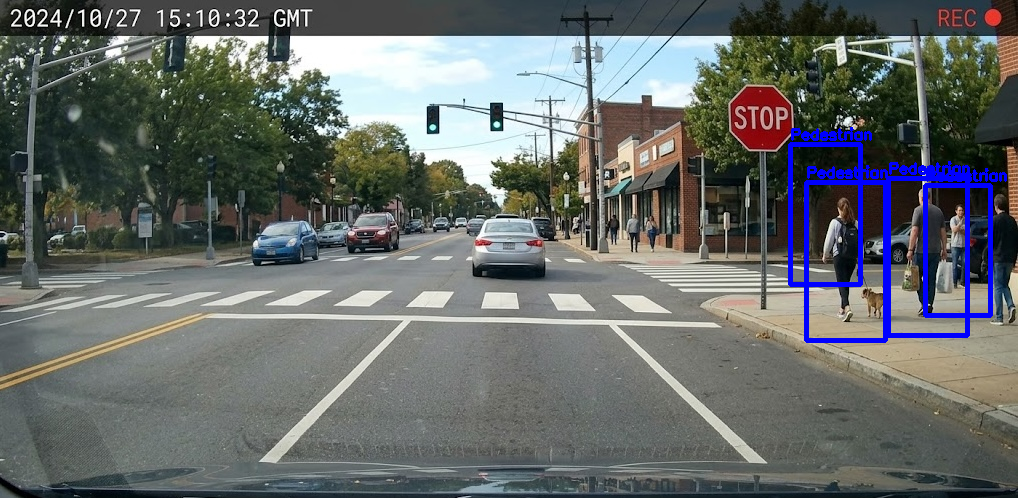

In [9]:
print("Locating pedestrians:")

# initialize the HOG descriptor/person detector
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# detect pedestrians
boxes, weights = hog.detectMultiScale(original_img, winStride=(4, 4), padding=(8, 8), scale=1.05)

# draw bounding boxes
pedestrian_img = original_img.copy()
for (x, y, w, h) in boxes:
    # draw blue rectangles on temporary and master images
    cv2.rectangle(pedestrian_img, (x, y), (x + w, y + h), (255, 0, 0), 3)
    cv2.putText(pedestrian_img, 'Pedestrian', (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    cv2.rectangle(display_img, (x, y), (x + w, y + h), (255, 0, 0), 3)
    cv2.putText(display_img, 'Pedestrian', (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

print(f"\nPedestrians Detected ({len(boxes)} found):")
cv2_imshow(pedestrian_img)

#### Identify Road Signs
Standard road signs are heavily characterized by specific colors. We convert the image to the **HSV (Hue, Saturation, Value)** color space, threshold it to isolate the color red, and use **Contour Detection** to find the boundaries of the Stop sign.

Identifying road signs:


Red Color Thresholding Mask:


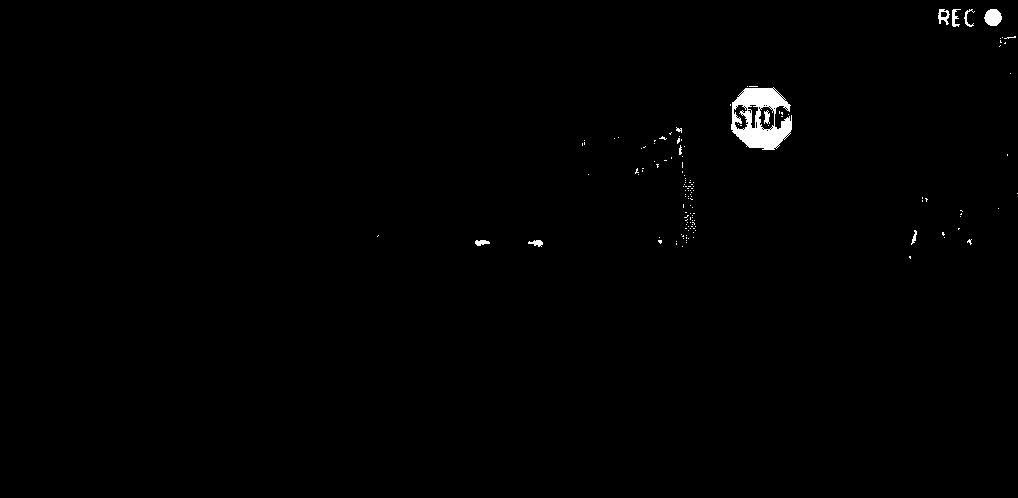


Isolated Road Signs:


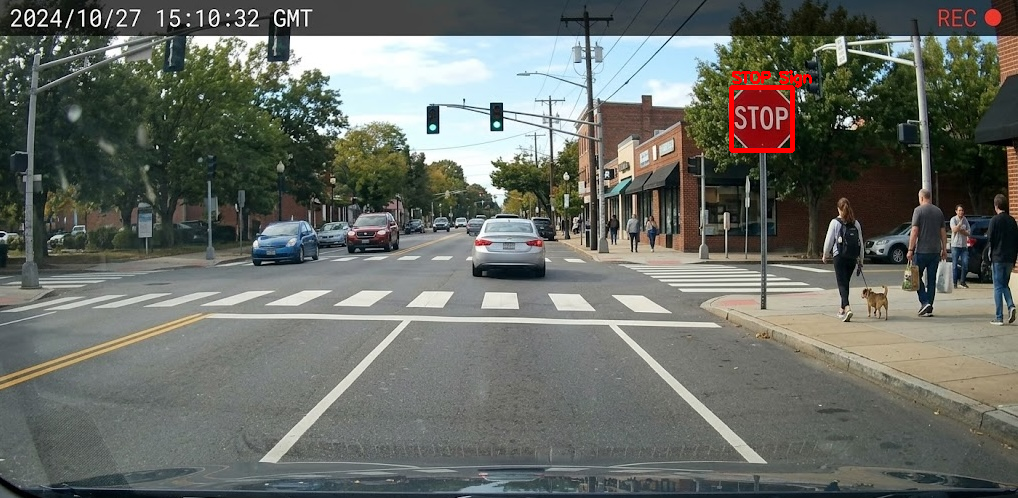

In [12]:
print("Identifying road signs:\n")

# convert to HSV color space
hsv = cv2.cvtColor(original_img, cv2.COLOR_BGR2HSV)

# define HSV ranges for the color Red
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])

# create a mask for red pixels
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
red_mask = mask1 + mask2

print("\nRed Color Thresholding Mask:")
cv2_imshow(red_mask)

# find contours of the red regions
contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

sign_img = original_img.copy()
for contour in contours:
    area = cv2.contourArea(contour)
    # filter out small red noise by enforcing a minimum area
    if area > 300:
        x, y, w, h = cv2.boundingRect(contour)

        # draw red rectangles on temporary and master images
        cv2.rectangle(sign_img, (x, y), (x + w, y + h), (0, 0, 255), 3)
        cv2.putText(sign_img, 'STOP Sign', (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        cv2.rectangle(display_img, (x, y), (x + w, y + h), (0, 0, 255), 3)
        cv2.putText(display_img, 'STOP Sign', (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

print("\nIsolated Road Signs:")
cv2_imshow(sign_img)

#### Final Output and Conclusion
By combining these isolated techniques, we have successfully built a unified perception frame.
* **Green Lines:** Detected Roadways/Markings
* **Blue Boxes:** Detected Pedestrians
* **Red Boxes:** Identified Road Signs


final unified perception output:


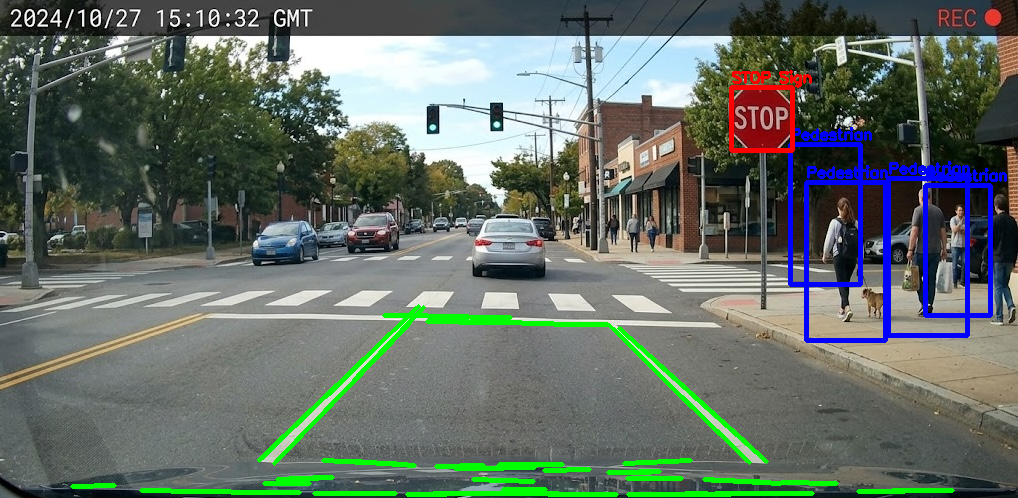

In [13]:
print("\nfinal unified perception output:")
cv2_imshow(display_img)